![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [206]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
#from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


In [5]:
bikes.shape

(10886, 12)

### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [ ]:
# Agrupar por las clases de la variable "Season" y calcular el máximo y mínimo en cada clase
estadisticas_por_clase = bikes.groupby('season').agg({
    'season': ['count'],  
    'total': ['max', 'min']  
})

estadisticas_por_clase.columns = ['Conteo', 'Máxima cantidad', 'Mínima cantidad']
print(estadisticas_por_clase)

        Conteo  Máxima cantidad  Mínima cantidad
season                                          
1         2686              801                1
2         2733              873                1
3         2733              977                1
4         2734              948                1


Análisis descriptivo para cada clase de la variable "season":

1-Invierno
* Promedio de bicicletas rentadas: 116 bicicletas
* Máximo de bicicletas rentadas: 801 bicicletas
* Cantidad de observaciones: 2.686 observaciones

2-Primavera
* Promedio de bicicletas rentadas: 215 bicicletas
* Máximo de bicicletas rentadas: 873 bicicletas
* Cantidad de observaciones: 2.733 observaciones

3-Verano
* Promedio de bicicletas rentadas: 234 bicicletas
* Máximo de bicicletas rentadas: 977 bicicletas
* Cantidad de observaciones: 2.733 observaciones

4-Otoño
* Promedio de bicicletas rentadas: 199 bicicletas
* Máximo de bicicletas rentadas: 948 bicicletas
* Cantidad de observaciones: 2.734 observaciones

Conclusiones a nivel general:
* El verano es la estación con el mayor promedio y máximo de bicicletas rentadas, indicando la popularidad de esta estación para esta actividad.
* Por el contrario, invierno presenta los valores más bajos tanto en promedio como en máximo de bicicletas rentadas, probablemente debido a las condiciones climáticas menos favorables en esta estación.
* El número de observaciones es uniforme entre las estaciones, con una ligera superioridad de otoño.

In [6]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [23]:
# Agrupar por las clases de la variable "Hour" y calcular el máximo y mínimo en cada clase
estadisticas_por_clase = bikes.groupby('hour').agg({
    'hour': ['count'],  
    'total': ['max', 'min']  
})

estadisticas_por_clase.columns = ['Conteo', 'Máxima cantidad', 'Mínima cantidad']
print(estadisticas_por_clase)

      Conteo  Máxima cantidad  Mínima cantidad
hour                                          
0        455              283                2
1        454              168                1
2        448              119                1
3        433               66                1
4        442               28                1
5        452               57                1
6        455              213                1
7        455              596                1
8        455              839                8
9        455              414               14
10       455              539               17
11       455              647               10
12       456              757                3
13       456              729               11
14       456              730               12
15       456              724                7
16       456              783               11
17       456              970               15
18       456              977               23
19       456 

Análisis descriptivo de la variable "hour":

1. **Promedio de bicicletas rentadas por hora:** Los valores promedio varían considerablemente según la hora. Las horas de la madrugada (como las 0:00, 1:00 y 2:00) presentan los promedios más bajos, con menos de 35 bicicletas rentadas por hora, lo cual refleja una baja actividad durante esas horas. En contraste, las horas de la tarde y la noche, especialmente entre las 17:00 y las 19:00, registran los promedios más altos, alcanzando hasta 469 bicicletas por hora a las 17:00. Esto evidencia que estas franjas horarias son las más activas, probablemente debido a la combinación de salidas recreativas y desplazamientos laborales.

2. **Máximo y mínimo de bicicletas rentadas por hora:** Los valores máximos de bicicletas rentadas son altos en las horas pico, especialmente a las 18:00, donde se alcanza el mayor registro con 977 bicicletas rentadas. Los valores mínimos son constantes a lo largo del día, siendo en su mayoría de solo 1 bicicleta rentada en las horas menos activas.

3. **Cantidad de observaciones:** La distribución de observaciones es uniforme para la mayoría de las horas, con cerca de 450 registros por hora, lo que asegura que el análisis sea representativo y confiable.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

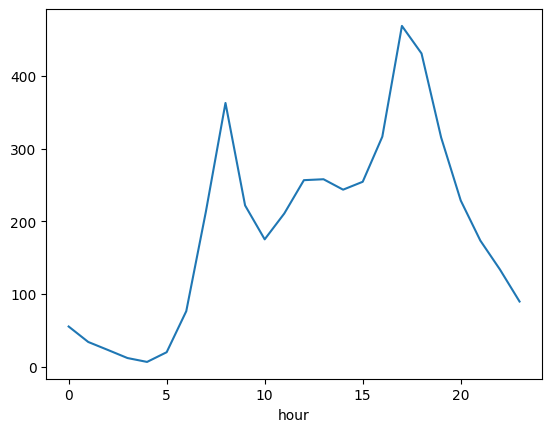

In [24]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

**Análisis:** En la gráfica se observa un aumento en el promedio dee bicicletas rentadas en los siguientes rangos horarios: de 05:00 a 08:00, de 10:00 a 12:00 y de 14:00 a 17:00. En este último intervalo, se registra el mayor promedio de biciciletas rentadas, superando las 400 bicicletas rentadas promedio a las 17:00.

(2686, 12)


<Axes: xlabel='hour'>

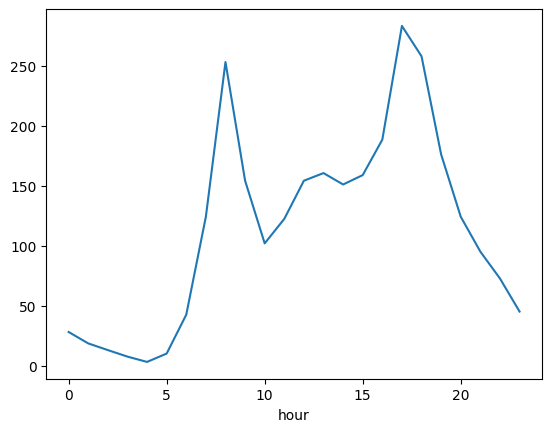

In [32]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 

# Filtrar datos cuando "season"=1
bikes_season1 = bikes[bikes['season'] == 1]
print(bikes_season1.shape)

bikes_season1.groupby('hour').total.mean().plot()

**Análisis:** La gráfica muestra un incremento en el promedio de bicicletas rentadas dentro de los siguientes rangos horarios: de 05:00 a 08:00, de 10:00 a 13:00 y de 14:00 a 17:00. En este último intervalo se registra el promedio más elevado, superando las 250 bicicletas rentadas a las 17:00. En invierno, destacan dos picos relevantes a las 08:00 y 17:00, donde el promedio de bicicletas rentadas también supera las 250 unidades.

(2733, 12)


<Axes: xlabel='hour'>

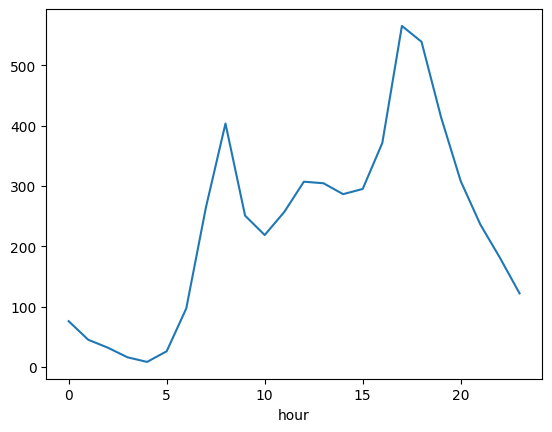

In [33]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 

# Filtrar datos cuando "season"=3
bikes_season3 = bikes[bikes['season'] == 3]
print(bikes_season3.shape)

bikes_season3.groupby('hour').total.mean().plot()

**Análisis:** La gráfica muestra un incremento notable en el promedio de bicicletas rentadas dentro de los siguientes rangos horarios: de 05:00 a 08:00, de 10:00 a 12:00 y de 15:00 a 17:00. En este último intervalo se registra el promedio más elevado, superando las 500 bicicletas rentadas a las 17:00. En comparación con el invierno, durante el verano el promedio de bicicletas rentadas en la hora pico de las 17:00 se duplica, reflejando una mayor demanda en esta estación.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [163]:
# Definir conjunto de variables predictoras
XTotal = bikes[['season', 'hour']]

# Definir variable de respuesta
yTotal = bikes[['total']]

# Dividir los conjuntos de datos en una partición de entrenamiento (67%) y de prueba (33%)
XTrain, XTest, yTrain, yTest = train_test_split(XTotal, yTotal, test_size=0.33, random_state=0)

In [156]:
# Ajustar el modelo de regresión lineal
modeloRL = LinearRegression()
modeloRL.fit(XTrain, yTrain)

# Predecir el total de bicicletas rentadas con modelo de regresión lineal
prediccionRL = modeloRL.predict(XTest)

# Generar métricas para el modelo de regresión lineal
MSE_RL = np.average(np.square(prediccionRL - yTest))
RMSE_RL = np.sqrt(MSE_RL)
print(f"RMSE del modelo de regresión lineal: {RMSE_RL:.2f}")
print()

# Imprimir los coeficientes del modelo de regresión lineal
print(f"Coeficientes del modelo:", modeloRL.coef_)
print()

# Evaluar modelo de regresión lineal con validación cruzada
scores = cross_val_score(modeloRL, XTotal, yTotal, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print("RMSE en cada fold:", rmse_scores)
print(f"RMSE promedio en la validación cruzada es : {rmse_scores.mean():.2f}")

RMSE del modelo de regresión lineal: 164.00

Coeficientes del modelo: [[28.03619568 10.57944293]]

RMSE en cada fold: [151.66796553 133.4597395  145.45181661 221.42364648 207.57894789]
RMSE promedio en la validación cruzada es : 171.92


Interpretación de los coeficientes:

* **Coeficiente para "season" (28.03619568):** Cada incremento en la categoría de estación (por ejemplo, pasar de invierno a primavera, primavera a verano) está asociado con un aumento promedio de 28.04 bicicletas rentadas, manteniendo constante el resto de las variables.
* **Coeficiente para "hour" (10.57944293):** Cada incremento en la hora del día (por ejemplo, de las 00:00 a las 01:00) está asociado con un aumento promedio de 10.58 bicicletas rentadas, manteniendo constante el resto de las variables.

Desempeño del modelo:
* **RMSE del modelo:** El valor de 164.00 indica que, en promedio, el modelo predice con un error de alrededor de 164 bicicletas, lo que podría ser alto considerando el rango de valores en la variable "total".
* **RMSE promedio en validación cruzada (171.92):** Este valor refleja la estabilidad del modelo al evaluar su desempeño en diferentes particiones del conjunto de datos. Aunque la dispersión entre los folds es notable (RMSE entre 133.46 y 221.42), el valor promedio sugiere que el modelo tiene un desempeño similar al conjunto de prueba.

Limitaciones del modelo de regresión lineal en este caso:
* La regresión lineal asume una relación lineal entre las variables predictoras y la variable de respuesta, lo cual es una simplificación excesiva debido a que en las gráficas del punto anterior, se observan picos de demanda durante ciertas horas según cada estación.
* La regresión no incluye interacciones entre las dos variables predictoras "season" y "hour". Por ejemplo, el impacto de la hora podría variar significativamente según la estación del año (por ejemplo, menos actividad en invierno durante las primeras horas del día).


### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [ ]:
# Definición de la función que calcula el gini index
def gini(y):
    if y.shape[0] == 0:
        return 0
    else:
        return 1 - (y.mean()**2 + (1 - y.mean())**2)

# Definición de la función gini_imputiry para calular la ganancia de una variable predictora j dado el punto de corte k
def gini_impurity(X, y, split):
    
    filter_l = X < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    gini_y = gini(y)
    gini_l = gini(y_l)
    gini_r = gini(y_r)
    
    gini_impurity_ = gini_y - (n_l / (n_l + n_r) * gini_l + n_r / (n_l + n_r) * gini_r)
    
    return gini_impurity_

# Definición de la función best_split para calcular cuál es la mejor variable y punto de corte para hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = gini_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = int(y.mean() >= 0.5) 
    y_prob = (y.sum() + 1.0) / (y.shape[0] + 2.0)  # Corrección Laplace 
    
    tree = dict(y_pred=y_pred, y_prob=y_prob, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree, proba=False):
    
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        if not proba:
            predicted = predicted * tree['y_pred']
        else:
            predicted = predicted * tree['y_prob']
            
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)

    return predicted

# Convertir yTotal en un serie para facilitar cálculos
y = yTotal['total']

# Implementar árbol de decisión
tree = tree_grow(XTotal, y, level=0, min_gain=0.001, max_depth=3, num_pct=10) #Con una profundidad máxima de 3 se generan 8 nodos finales

# Predecir 
tree_predict(XTotal, tree)

array([1., 1., 1., ..., 1., 1., 1.], shape=(10886,))

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

Consideraciones:

En el punto 3 se divide el conjunto de variables predictoras y la variable de respuesta en dos particiones, 67% para entrenamiento y 33% para prueba. Como la idea es calibrar el párametro max_depth (profundidad) del árbol de decisión, vamos a utilizar la partición de entrenamiento para calibrar el parámetro y medir el desempeño a través de validacion cruzada, y la partición de prueba (33%) se utilizará como partición de validación para medir el desempeño del árbol de decisión con el párametro calibrado.

In [ ]:
# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 21)

# Lista para guardar los valores del RMSE para cada valor de máxima profundidad (max_depth)
rmse_scores_cal = []

# Implementar ciclo para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    dtr = DecisionTreeRegressor(max_depth=depth, random_state=1)
    mse_scores_cal = cross_val_score(dtr, XTrain, yTrain, cv=10, scoring='neg_mean_squared_error')
    rmse_scores_cal.append((-mse_scores_cal.mean())**0.5)

# Imprimer mejor RMSE (menor error) y su correspondiente max_depth
best_rmse, best_depth = sorted(zip(rmse_scores, max_depth_range))[0]
print(f"Con una profundidad (max_depth) de {best_depth}, se obtiene el mejor RMSE: {best_rmse:.2f}")

Con una profundidad (max_depth) de 2, se obtiene el mejor RMSE: 133.46


In [ ]:
# Ajustar un árbol usando max_depth = 2 
modeloDTR = DecisionTreeRegressor(max_depth=5, random_state=1)
modeloDTR.fit(XTrain, yTrain)

# Predecir el total de bicicletas rentadas con el árbol de decisión calibrado
prediccionDTR = modeloDTR.predict(XTest)

# Convertir a serier para facilitar los calculos
yTest = yTest['total']

# Generar métricas de desempeño para el árbol de decisión
MSE_DTR = np.average(np.square(prediccionDTR - yTest))
RMSE_DTR = np.sqrt(MSE_DTR)
print(f"RMSE del árbol de decisión es: {RMSE_DTR:.2f}")

RMSE del árbol de decisión es: 121.60


Análisis:

* Menor RMSE: El árbol de decisión con una profundidad máxima de 2 presenta un RMSE de 121.60, que es menor al RMSE del modelo de regresión lineal con validación cruzada (171.92). Esto indica que el árbol de decisión tiene mejor capacidad para ajustar los datos y capturar la relación entre las variables predictoras y la variable de respuesta.
* Capacidad de modelar relaciones no lineales: Los árboles de decisión son capaces de capturar relaciones no lineales entre las variables predictoras ("season" y "hour") y la variable de respuesta ("total"). Esto probablemente contribuye al mejor desempeño del árbol frente a la regresión lineal, que asume una relación estrictamente lineal entre las variables.
* Regularización por max_depth: Al limitar la profundidad máxima del árbol a 2, se evita un crecimiento excesivo que podría llevar a sobreajuste, lo cual mejora la generalización del modelo. Este ajuste del hiperparámetro parece haber sido eficaz, ya que el desempeño del árbol supera al modelo lineal.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [167]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [168]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [169]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [171]:
# Implementar un árbol de decisión calibrando el párametro profundidad (max_depth) a través de validación cruzada

# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 21)

# Lista para guardar la exactitud para cada valor de máxima profundidad (max_depth)
accuracy_scores = []

# Implementar ciclo para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=1)
    accuracy_scores.append(cross_val_score(dtc, X_train, y_train, cv=10, scoring='accuracy').mean())

# Mejor accuracy (desempeño del modelo) y su correspondiente max_depth
sorted(zip(accuracy_scores, max_depth_range))[::-1][0]

(np.float64(0.6308888888888888), 2)

In [176]:
# max_depth=4 fue el mejor, se ajusta un árbol usando este valor 
modeloDTC = DecisionTreeClassifier(max_depth=2, random_state=1)
modeloDTC.fit(X_train, y_train)

# Predecir si la noticia es popular o no con el árbol de decisión calibrado
prediccionDTC = modeloDTC.predict(X_test)

# Calcular accuracy (exactitud)
accuracy_DTC = accuracy_score(y_test, prediccionDTC)
print(f"El accuracy (exactitud) del árbol de decisión calibrado es: {accuracy_DTC:.2f}")
print()

# Calcular F1-score
f1_DTC = f1_score(y_test, prediccionDTC)  
print(f"EL F1-Score del árbol de decisión calibrado es: {f1_DTC:.2f}")

El accuracy (exactitud) del árbol de decisión calibrado es: 0.65

EL F1-Score del árbol de decisión calibrado es: 0.64


In [ ]:
# Implementar un modelo de regresión logística

# Crear el modelo de regresión logística
modeloRLog = LogisticRegression(random_state=1, max_iter=1000)  
modeloRLog.fit(X_train, y_train) 

# Predecir si la noticia es popular o no con el modelo de regresión logística
prediccionRLog = modeloRLog.predict(X_test)

# Calcular accuracy (exactitud)
accuracy_RLog = accuracy_score(y_test, prediccionRLog)
print(f"El accuracy (exactitud) del árbol de decisión calibrado es: {accuracy_RLog:.2f}")
print()

# Calcular F1-score
f1_RLog = f1_score(y_test, prediccionRLog)  
print(f"EL F1-Score del árbol de decisión calibrado es: {f1_RLog:.2f}")

El accuracy (exactitud) del árbol de decisión calibrado es: 0.62

EL F1-Score del árbol de decisión calibrado es: 0.60


Análisis de desempeño de cada modelo:

1. Árbol de decisión:

* Un Accuracy de 0.65 indica que el 65% de las predicciones realizadas son correctas.
* Un F1-Score de 0.64 refleja un buen balance entre precisión (proporción de verdaderos positivos sobre todos los positivos predichos) y recall (proporción de verdaderos positivos sobre todos los positivos reales). Esto indica que el modelo tiene un rendimiento equilibrado, lo cual es importante dado el objetivo de predecir si una noticia es popular o no.

2. Regresión logística:

* Un Accuracy de 0.62 indica que el 62% de predicciones correctas.
* Su F1-Score de 0.60 indica que tiene un balance algo menor entre precisión y recall en comparación con el árbol de decisión, lo que podría indicar dificultades para manejar los datos en términos de capturar correctamente las verdaderas noticias populares frente a las no populares.

Comparación de modelos:

* El árbol de decisión tiene un desempeño superior en ambas métricas: accuracy y F1-score. Esto sugiere que el árbol de decisión es más adecuado para predecir si la noticia es popular o no, posiblemente gracias a su capacidad para modelar relaciones no lineales y segmentar mejor los datos en base a las características predictoras.



### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [ ]:
# Creación de 100 muestras de bootstrap
n_estimators_modelo1 = 100
np.random.seed(123)

n_samples_modelo1 = X_train.shape[0]
samples_modelo1 = [np.random.choice(a=n_samples_modelo1, size=n_samples_modelo1, replace=True) for _ in range(n_estimators_modelo1)]

np.random.seed(123) 
seeds_modelo1 = np.random.randint(1, 10000, size=n_estimators_modelo1)

# Entrenamiento del primer modelo: árboles de decisión con max_depth (profundidad) = 5
trees_max_depth = {}
y_pred_max_depth = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators_modelo1)))
for i in range(n_estimators_modelo1):
    trees_max_depth[i] = DecisionTreeClassifier(max_features="sqrt", max_depth=5, random_state=seeds_modelo1[i])
    trees_max_depth[i].fit(X_train.iloc[samples_modelo1[i]], y_train.iloc[samples_modelo1[i]])
    y_pred_max_depth.iloc[:, i] = trees_max_depth[i].predict(X_test)

# Votación mayoritaria del primer modelo
y_pred_modelo1 = (y_pred_max_depth.sum(axis=1) >= (n_estimators_modelo1 / 2)).astype(np.int64)

# Evaluar desempeño del primer modelo
accuracy_DT1 = accuracy_score(y_test, y_pred_modelo1)
print(f"El accuracy (exactitud) del árbol de decisión con max_depth fijo es: {accuracy_DT1:.2f}")
f1_DT1 = f1_score(y_test, y_pred_modelo1)  
print(f"EL F1-Score del árbol de decisión con max_depth fijo es: {f1_DT1:.2f}")

El accuracy (exactitud) del árbol de decisión con max_depth fijo es: 0.67
EL F1-Score del árbol de decisión con max_depth fijo es: 0.67



In [203]:
# Creación de 100 muestras de bootstrap
n_estimators_modelo2 = 100
np.random.seed(123)

n_samples_modelo2 = X_train.shape[0]
samples_modelo2 = [np.random.choice(a=n_samples_modelo2, size=n_samples_modelo2, replace=True) for _ in range(n_estimators_modelo2)]

np.random.seed(123) 
seeds_modelo2 = np.random.randint(1, 10000, size=n_estimators_modelo2)

# Entrenamiento del segundo modelo: árboles de decisión con min_samples_leaf=10
trees_min_samples_leaf = {}
y_pred_min_samples_leaf = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators_modelo2)))
for i in range(n_estimators_modelo2):
    trees_min_samples_leaf[i] = DecisionTreeClassifier(max_features="sqrt", min_samples_leaf=10, random_state=seeds_modelo2[i])
    trees_min_samples_leaf[i].fit(X_train.iloc[samples_modelo2[i]], y_train.iloc[samples_modelo2[i]])
    y_pred_min_samples_leaf.iloc[:, i] = trees_max_depth[i].predict(X_test)

# Votación mayoritaria del segundo modelo
y_pred_modelo2 = (y_pred_min_samples_leaf.sum(axis=1) >= (n_estimators_modelo2 / 2)).astype(np.int64)

# Evaluar desempeño del primer modelo
accuracy_DT2 = accuracy_score(y_test, y_pred_modelo2)
print(f"El accuracy (exactitud) del árbol de decisión con min_samples_leaf fijo es: {accuracy_DT2:.2f}")
f1_DT2 = f1_score(y_test, y_pred_modelo2)  
print(f"EL F1-Score del árbol de decisión con min_samples_leaf fijo es: {f1_DT2:.2f}")

El accuracy (exactitud) del árbol de decisión con min_samples_leaf fijo es: 0.67
EL F1-Score del árbol de decisión con min_samples_leaf fijo es: 0.67


In [204]:
# Creación de 100 muestras de bootstrap
n_estimators_modelo3 = 100
np.random.seed(123)

n_samples_modelo3 = X_train.shape[0]
samples_modelo3 = [np.random.choice(a=n_samples_modelo3, size=n_samples_modelo3, replace=True) for _ in range(n_estimators_modelo3)]

np.random.seed(123) 
seeds = np.random.randint(1, 10000, size=n_estimators_modelo3)

# Entrenamiento del tercer modelo: regresión logística
logistics = {}
y_pred_logistic = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators_modelo3)))
for i in range(n_estimators_modelo3):
    logistics[i] = LogisticRegression(random_state=seeds[i], max_iter=200)  
    logistics[i].fit(X_train.iloc[samples_modelo3[i]], y_train.iloc[samples_modelo3[i]])
    y_pred_logistic.iloc[:, i] = logistics[i].predict(X_test)

# Votación mayoritaria del segundo modelo
y_pred_modelo3 = (y_pred_logistic.sum(axis=1) >= (n_estimators_modelo3 / 2)).astype(np.int64)

# Evaluar desempeño del primer modelo
accuracy_RL= accuracy_score(y_test, y_pred_modelo3)
print(f"El accuracy (exactitud) del modelo de regresión logística es: {accuracy_RL:.2f}")
f1_RL = f1_score(y_test, y_pred_modelo3)  
print(f"EL F1-Score del modelo de regresión logística es: {f1_RL:.2f}")

El accuracy (exactitud) del modelo de regresión logística es: 0.61
EL F1-Score del modelo de regresión logística es: 0.61


In [205]:
# Cálculo del umbral ajustado
threshold = (n_estimators_modelo1 + n_estimators_modelo2 + n_estimators_modelo3) / 2

# Suma de las predicciones positivas de cada conjunto de modelos
predicciones_positivas = (y_pred_max_depth.sum(axis=1) + y_pred_min_samples_leaf.sum(axis=1) + y_pred_logistic.sum(axis=1)) 

# Votación mayoritaria del ensamblaje
final_predictions = (predicciones_positivas >= threshold).astype(int)

# Evaluar desempeño del primer modelo
accuracy_ensamblaje = accuracy_score(y_test, final_predictions)
print(f"El accuracy (exactitud) del esamblaje es: {accuracy_ensamblaje:.2f}")
f1_ensamblaje = f1_score(y_test, final_predictions)  
print(f"EL F1-Score del esamblaje es: {f1_ensamblaje:.2f}")

El accuracy (exactitud) del esamblaje es: 0.65
EL F1-Score del esamblaje es: 0.64


Análisis:

1. Árbol de decisión con max_depth fijo:
* Accuracy: 0.67
* F1-Score: 0.67
Observamos un rendimiento equilibrado entre estas métricas. Esto sugiere que el modelo predice con precisión tanto la clase positiva como la negativa, sin un sesgo evidente.

2. Árbol de decisión con min_samples_leaf fijo:
* Accuracy: 0.67
* F1-Score: 0.67
Los resultados son idénticos a los obtenidos con max_depth fijo. Esto puede indicar que ambas configuraciones están capturando patrones similares en los datos.

3. Regresión logística:
* Accuracy: 0.61 
* F1-Score: 0.61 
Este modelo muestra un rendimiento ligeramente inferior al de los árboles de decisión, lo que podría deberse a que no captura bien las relaciones no lineales presentes en los datos.

4. Ensamblaje de modelos:
* Accuracy: 0.65
* F1-Score: 0.64
El ensamblaje no logró superar a los modelos individuales de árboles de decisión en ninguna de las dos métricas (Accuracy y F1-Score). Sin embargo, sí mejoró con respecto al modelo de regresión logística. Este resultado muestra que el ensamblaje promedio suavizó los errores del modelo más débil (regresión logística) pero no explotó significativamente los beneficios del bagging en este caso.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [216]:
samples_oob_modelo1 = []
# Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
for sample in samples_modelo1:
    samples_oob_modelo1.append(sorted(set(range(n_samples_modelo1)) - set(sample)))

# Estimación de los errores OOB para cada clasificador
errors_modelo1 = np.zeros(n_estimators_modelo1)

for i in range(n_estimators_modelo1):
    y_pred_max_depth_pon = trees_max_depth[i].predict(X_train.iloc[samples_oob_modelo1[i]])
    errors_modelo1[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob_modelo1[i]], y_pred_max_depth_pon)

# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha_modelo1 = (1 - errors_modelo1) / (1 - errors_modelo1).sum()

# Ponderación de las predicciones con los pesos alpha
weighted_sum_1_modelo1 = ((y_pred_max_depth) * alpha_modelo1).sum(axis=1)
weighted_sum_1_modelo1.head(20)

# Desempeño al hacer votación ponderada
y_pred_modelo1_pon = (weighted_sum_1_modelo1 >= 0.5).astype(np.int64)
accuracy_DT1_pon = accuracy_score(y_test, y_pred_modelo1_pon)
print(f"El accuracy (exactitud) del árbol de decisión con max_depth fijo es: {accuracy_DT1_pon:.2f}")
f1_DT1_pon = f1_score(y_test, y_pred_modelo1_pon)  
print(f"EL F1-Score del árbol de decisión con max_depth fijo es: {f1_DT1_pon:.2f}")

El accuracy (exactitud) del árbol de decisión con max_depth fijo es: 0.67
EL F1-Score del árbol de decisión con max_depth fijo es: 0.66


In [ ]:
samples_oob_modelo2 = []
# Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
for sample in samples_modelo2:
    samples_oob_modelo2.append(sorted(set(range(n_samples_modelo2)) - set(sample)))

# Estimación de los errores OOB para cada clasificador
errors_modelo2 = np.zeros(n_estimators_modelo2)

for i in range(n_estimators_modelo2):
    y_pred_min_samples_leaf_pon = trees_min_samples_leaf[i].predict(X_train.iloc[samples_oob_modelo2[i]])
    errors_modelo2[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob_modelo2[i]], y_pred_min_samples_leaf_pon)

# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha_modelo2 = (1 - errors_modelo2) / (1 - errors_modelo2).sum()

# Ponderación de las predicciones con los pesos alpha
weighted_sum_1_modelo2 = ((y_pred_min_samples_leaf) * alpha_modelo2).sum(axis=1)
weighted_sum_1_modelo2.head(20)

# Desempeño al hacer votación ponderada
y_pred_modelo2_pon = (weighted_sum_1_modelo2 >= 0.5).astype(np.int64)
accuracy_DT2_pon = accuracy_score(y_test, y_pred_modelo2_pon)
print(f"El accuracy (exactitud) del árbol de decisión con min_samples_leaf fijo es: {accuracy_DT2_pon:.2f}")
f1_DT2_pon = f1_score(y_test, y_pred_modelo2_pon)  
print(f"EL F1-Score del árbol de decisión con min_samples_leaf fijo es: {f1_DT2_pon:.2f}")

El accuracy (exactitud) del árbol de decisión con min_samples_leaf fijo es: 0.67
EL F1-Score del árbol de decisión con min_samples_leaf fijo es: 0.66


In [218]:
samples_oob_modelo3 = []
# Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
for sample in samples_modelo3:
    samples_oob_modelo3.append(sorted(set(range(n_samples_modelo3)) - set(sample)))

# Estimación de los errores OOB para cada clasificador
errors_modelo3 = np.zeros(n_estimators_modelo3)

for i in range(n_estimators_modelo3):
    y_pred_logistic_pon = logistics[i].predict(X_train.iloc[samples_oob_modelo3[i]])
    errors_modelo3[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob_modelo3[i]], y_pred_logistic_pon)

# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha_modelo3 = (1 - errors_modelo3) / (1 - errors_modelo3).sum()

# Ponderación de las predicciones con los pesos alpha
weighted_sum_1_modelo3 = ((y_pred_logistic) * alpha_modelo3).sum(axis=1)
weighted_sum_1_modelo3.head(20)

# Desempeño al hacer votación ponderada
y_pred_modelo3_pon = (weighted_sum_1_modelo3 >= 0.5).astype(np.int64)
accuracy_RL_pon= accuracy_score(y_test, y_pred_modelo3_pon)
print(f"El accuracy (exactitud) del modelo de regresión logística es: {accuracy_RL_pon:.2f}")
f1_RL_pon = f1_score(y_test, y_pred_modelo3_pon)  
print(f"EL F1-Score del modelo de regresión logística es: {f1_RL_pon:.2f}")

El accuracy (exactitud) del modelo de regresión logística es: 0.61
EL F1-Score del modelo de regresión logística es: 0.61


In [ ]:
# Combinación de las predicciones ponderadas
combined_weighted_sum = weighted_sum_1_modelo1 + weighted_sum_1_modelo2 + weighted_sum_1_modelo3

# Determinar la clase final
y_pred_ensamble_pon = (combined_weighted_sum >= 0.5).astype(int)

# Evaluar desempeño del primer modelo
accuracy_ensamblaje_pon = accuracy_score(y_test, y_pred_ensamble_pon)
print(f"El accuracy (exactitud) del esamblaje es: {accuracy_ensamblaje_pon:.2f}")
f1_ensamblaje_pon = f1_score(y_test, y_pred_ensamble_pon)  
print(f"EL F1-Score del esamblaje es: {f1_ensamblaje_pon:.2f}")

El accuracy (exactitud) del esamblaje es: 0.63
EL F1-Score del esamblaje es: 0.70


Análisis para votación ponderada

1. Árbol de decisión con max_depth fijo:
* Accuracy: 0.67
* F1-Score: 0.66
Este modelo muestra un desempeño sólido, con métricas consistentes. La ligera diferencia entre Accuracy y F1-Score podría deberse a pequeñas variaciones en las predicciones de clase positiva y negativa. En general, el modelo es balanceado.

2. Árbol de decisión con min_samples_leaf fijo:
* Accuracy: 0.67
* F1-Score: 0.66
Exactamente el mismo desempeño que el modelo con max_depth. Esto sugiere que ambos capturan patrones similares en los datos, sin que uno tenga una ventaja clara sobre el otro en términos de generalización.

3. Regresión logística:
* Accuracy: 0.61 
* F1-Score: 0.61 
Es el modelo con peor desempeño. Dado que es lineal, probablemente no captura bien las relaciones no lineales en los datos, lo que resulta en un menor rendimiento general.

4. Ensamblaje de modelos:
* Accuracy de 0.63: El ensamblaje tiene una Accuracy menor que los árboles individuales (0.67). Este comportamiento sugiere que el ensamblaje, al incluir un modelo débil (la regresión logística), está perdiendo precisión al combinar predicciones. Los predicciones ponderados suavizan los resultados, pero no logran superar a los mejores modelos individuales en términos de exactitud.
* F1-Score de 0.70: Sin embargo, el ensamblaje logra un F1-Score más alto (0.70) que cualquiera de los modelos individuales.Esto indica que el ensamblaje está equilibrando mejor la precision (porcentaje de predicciones "positivas" correctas) y el Recall (capacidad de detectar correctamente las clases positivas). Este comportamiento es típico de la votación ponderada, que prioriza modelos confiables y ayuda a reducir errores en clases minoritarias.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

**Votación Mayoritaria**

* Accuracy: 0.65
* F1-Score: 0.64

Ventajas:
* La votación mayoritaria utiliza un enfoque directo, donde cada modelo tiene el mismo peso en la decisión final. Esto facilita la implementación y no requiere cálculos adicionales como los errores OOB.
* Este método se beneficia de que al combinar las predicciones de 300 modelos, tiende a reducir el impacto de errores individuales.
* Las predicciones son intuitivas; una observación se clasifica según la mayoría de los modelos predigan la misma clase.

Desventajas:
* Modelos con menor precisión (como la regresión logística) tienen el mismo peso que modelos más precisos (como los árboles de decisión). Esto puede afectar negativamente la calidad de las predicciones finales.
* El desempeño observado es inferior al esperado en comparación con otros métodos como la votación ponderada.

**Votación Ponderada**

* Accuracy: 0.63
* F1-Score: 0.70

Ventajas:
* Los pesos asignados a los modelos a través de los errores OOB permiten dar más influencia a aquellos con mejor desempeño. Esto favorece una combinación informada y optimizada.
* La votación ponderada logró un F1-Score superior (0.70), lo que indica que maneja mejor el balance entre precision (precisión) y recall (sensibilidad). Esto la hace ideal para problemas donde ambas métricas son críticas.
* Permite ajustar los pesos según criterios adicionales o específicos, adaptándose a las necesidades del problema.

Desventajas:
* La estimación de los errores OOB y el cálculo de pesos aumenta la complejidad computacional en comparación con la votación mayoritaria.
* Aunque se optimizan los resultados en F1-Score, la Accuracy es ligeramente inferior (0.63 frente a 0.65). Esto podría no ser ideal en problemas donde la exactitud general sea primordial.